# Import necessary libraries

In [14]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
from sklearn.preprocessing import StandardScaler
import math
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

# Remove warning 

In [15]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [16]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [17]:
df.shape

(77536, 186)

# Feature Selection

In [18]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [19]:
df=df[features]

# Remove duplicate data points

In [20]:
# Remove duplicate rows and get the original DataFrame without duplicates
df_without_duplicates = df.drop_duplicates()
df=df_without_duplicates
df.shape

(71522, 11)

# Convert time string to seconds function

In [21]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Convert latitude and longitude into Cartesian coordinates

In [22]:
import pandas as pd
import math

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Scale the Cartesian coordinates between -1 and 1 using Min-Max scaling
df['OSD.latitude'] = 2 * (df['local_x'] - df['local_x'].min()) / (df['local_x'].max() - df['local_x'].min()) - 1
df['OSD.longitude'] = 2 * (df['local_y'] - df['local_y'].min()) / (df['local_y'].max() - df['local_y'].min()) - 1

# Drop the 'local_x' and 'local_y' columns
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.999882,0.999001,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [23]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

# Handle the Outliers

In [24]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 7  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)
    
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)

Shape of original DataFrame: (71522, 22)
Shape of filtered DataFrame (after removing outliers): (64356, 22)


In [25]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
77530,931.0,1024,1024,364,1024,-0.998428,-0.990589,1.9,6.2,-3.7,42.7
77531,931.1,1024,1024,364,1024,-0.998428,-0.990589,1.9,6.0,-3.7,42.4
77532,931.2,1024,1024,364,1024,-0.998427,-0.990588,1.9,5.3,-3.6,42.0
77533,931.3,1024,1024,364,1024,-0.998427,-0.990588,1.9,4.8,-1.5,41.5


# Normalize other features

In [26]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.459063,0.035987,-0.524142,0.128677,-0.018592,5.436911,5.434930,-0.573543,1.215106,1.40385,1.195496
2,-1.458700,0.035987,-0.524142,0.128677,-0.018592,5.436910,5.434931,-0.573543,1.215106,1.40385,1.195496
3,-1.458337,0.035987,-0.524142,0.128677,-0.018592,5.436910,5.434931,-0.573543,1.215106,1.40385,1.195496
4,-1.457975,0.035987,-0.524142,0.128677,-0.018592,5.436909,5.434930,-0.573543,1.215106,1.40385,1.196584
5,-1.457612,0.035987,-0.524142,0.128677,-0.018592,5.436909,5.434931,-0.573543,1.215106,1.40385,1.196584


Accuracy for OSD.longitude: 99.55%
Accuracy for OSD.latitude: 99.56%
Accuracy for OSD.height [ft]: 99.54%
Accuracy for OSD.pitch: 99.51%
Accuracy for OSD.roll: 99.23%
Accuracy for OSD.yaw: 99.49%


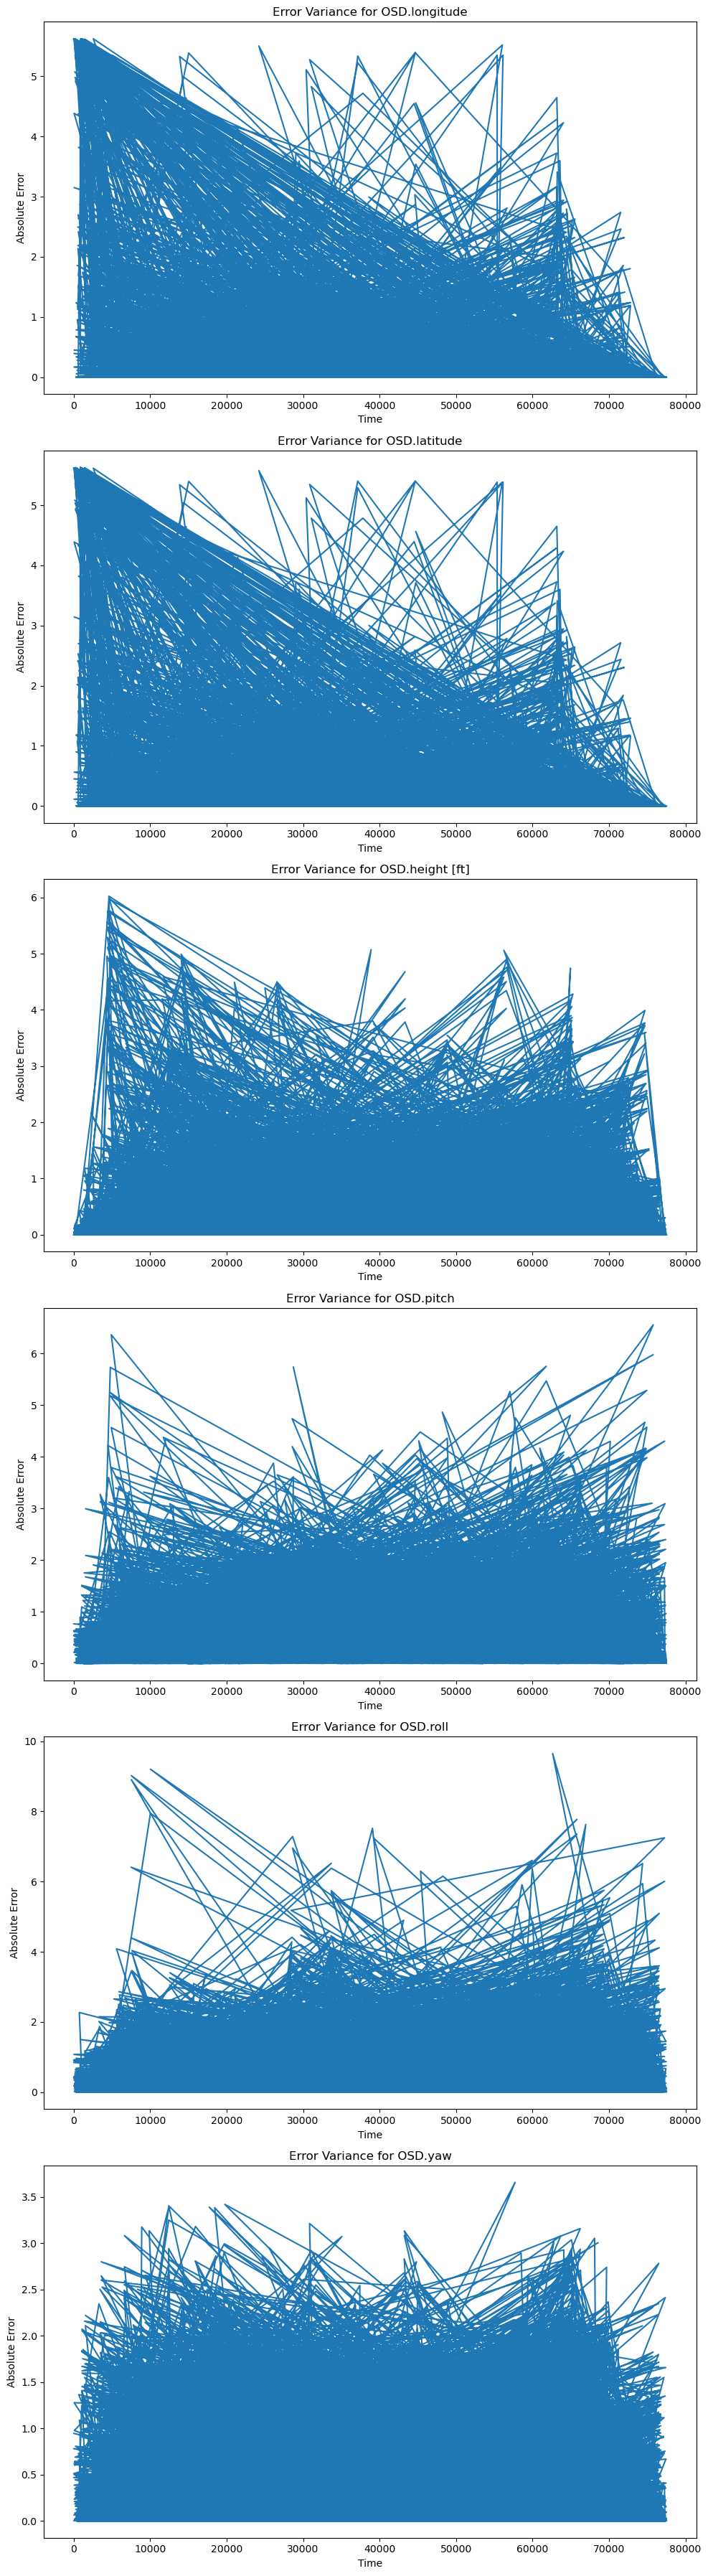

In [31]:
# Define input features and output targets
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

X = df[input_features]
y = df[output_targets]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a multi-output regression model (Random Forest Regressor in this case)
base_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
multi_output_regressor = MultiOutputRegressor(base_regressor)

# Train the multi-output regression model
multi_output_regressor.fit(X_train, y_train)
# Predict on the testing set
y_pred = multi_output_regressor.predict(X_test)
# Calculate the error for each predicted feature
errors = y_test - y_pred
mean_errors = np.mean(errors, axis=0)
# Calculate the mean squared error (MSE) for each predicted feature
mse_per_feature = np.mean((errors ** 2), axis=0)
# Display accuracy for each predicted feature
for i, target in enumerate(output_targets):
    print(f"Accuracy for {target}: {100 - mse_per_feature[i]:.2f}%")
# Create subplots for each predicted feature
fig, axs = plt.subplots(len(output_targets), figsize=(10, 6 * len(output_targets)))
# Plot error variance for each predicted feature
for i, target in enumerate(output_targets):
    axs[i].plot(y_test.index, np.abs(errors[target]))
    axs[i].set_title(f'Error Variance for {target}')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()

Accuracy on custom test set: -1441.79%


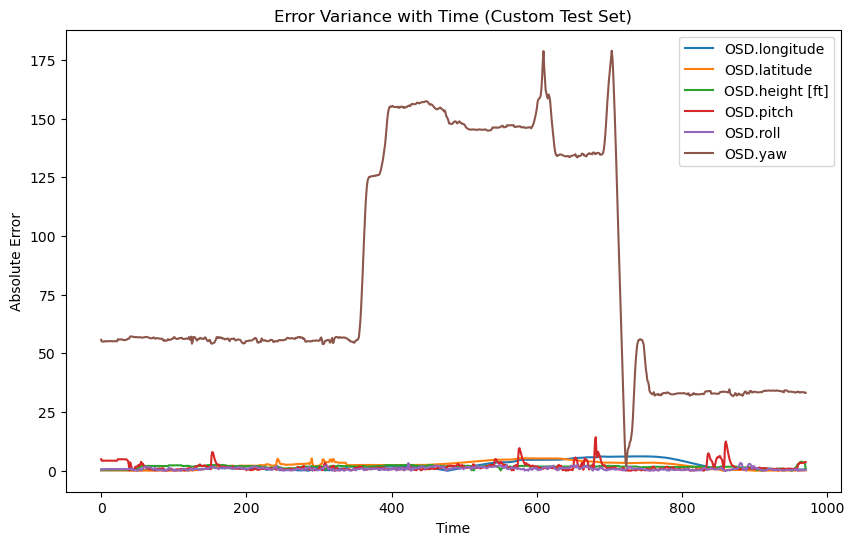

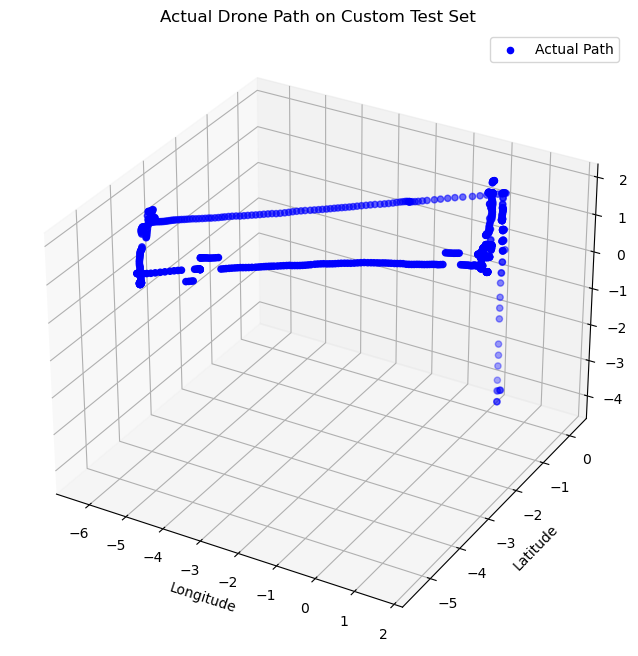

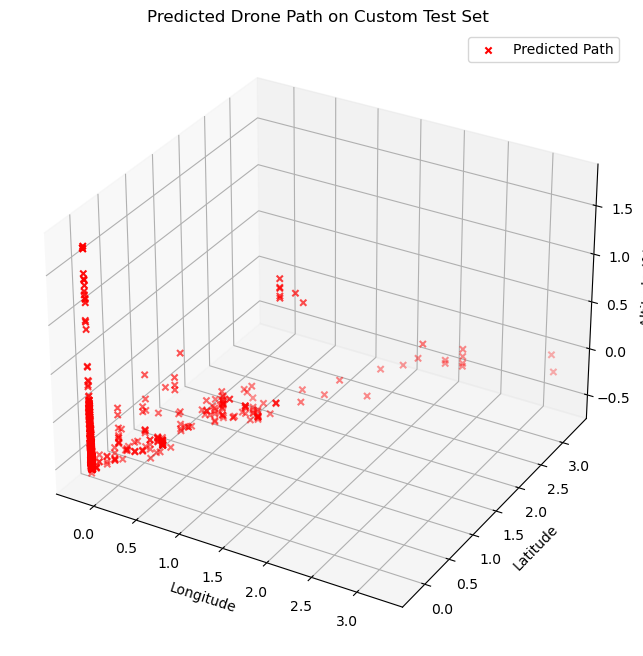

In [44]:
# Read the custom test dataset and preprocess it
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Remove duplicates from the dataset
df_test_custom = df_test_custom.drop_duplicates()

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)

# Instantiate the StandardScaler
scaler = StandardScaler()
X_test_custom_normalized = scaler.fit_transform(df_test_custom[input_features])

# Use the pre-trained model to predict output targets for the custom test dataset
y_pred_custom = multi_output_regressor.predict(X_test_custom_normalized)

# Calculate accuracy metrics for each predicted feature on the custom test set
mse_custom = mean_squared_error(df_test_custom[output_targets], y_pred_custom)
accuracy_custom = 100 - mse_custom
print(f"Accuracy on custom test set: {accuracy_custom:.2f}%")

# Plot error variance with time for each predicted feature
plt.figure(figsize=(10, 6))
for i, target in enumerate(output_targets):
    plt.plot(df_test_custom.index, np.abs(df_test_custom[target] - y_pred_custom[:, i]), label=target)
plt.title('Error Variance with Time (Custom Test Set)')
plt.xlabel('Time')
plt.ylabel('Absolute Error')
plt.legend()


## Create a 3D plot for the actual drone path on the custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on the custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()
# Show the combined plot
plt.show()



In [42]:
mse_custom

1541.7854724496049